In [ ]:
### plotting campari counting data



In [1]:
csv_th    = r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\CaMPARI_HCR_reg\th_activity_quant.csv"
csv_tac3b = r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\tac3b_tbr1a\tac3b_quant.csv"


Processing: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\CaMPARI_HCR_reg\th_activity_quant.csv  (mode=th)
df  print out     sample odor  active_percent
0   TCA_b1  TCA       26.865672
1   TCA_b3  TCA       28.260870
2   TCA_b4  TCA       28.671329
3   TCA_b5  TCA       32.743363
4   ATP_b1  ATP       10.169492
5   ATP_b2  ATP       13.333333
6   ATP_b3  ATP       14.285714
7   ATP_b4  ATP        9.482759
8   Cyt_b1  Cyt       29.752066
9   Cyt_b2  Cyt       26.771654
10  Cyt_b3  Cyt       22.307692
11  Cyt_b4  Cyt       27.450980
12  Cyt_b5  Cyt       25.362319
13   E3_b1   E3       16.030534
14   E3_b2   E3       26.415094
15   E3_b3   E3       23.966942
16   E3_b5   E3       14.406780


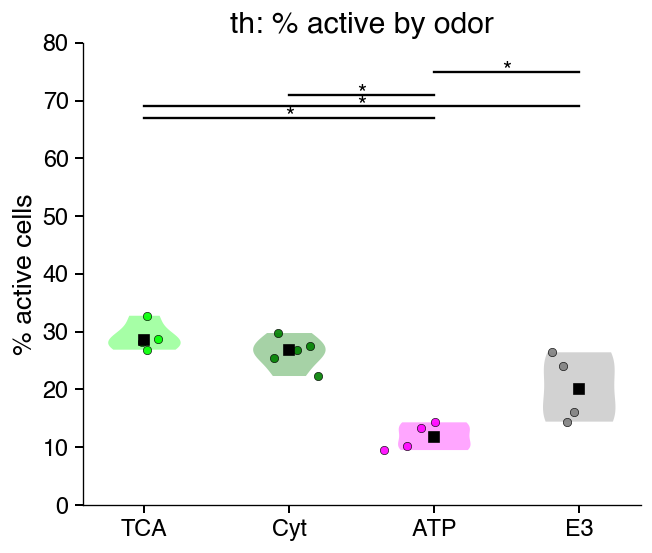

  Saved single-panel: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\th_percent_violin_helv.svg
Processing: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\tac3b_tbr1a\tac3b_quant.csv  (mode=Tac3b)
df  print out     sample odor  active_percent
0   Cyt_b1  Cyt       35.106383
1   Cyt_b2  Cyt       30.864198
2   Cyt_b3  Cyt       36.000000
3   Cyt_b4  Cyt       33.750000
4   Cyt_b5  Cyt       24.137931
5   Cyt_b6  Cyt       35.294118
6   ATP_b2  ATP       57.608696
7   ATP_b3  ATP       61.250000
8   ATP_b4  ATP       45.000000
9   ATP_b6  ATP       45.871560
10  TCA_b2  TCA       31.395349
11  TCA_b3  TCA       28.125000
12  TCA_b5  TCA       36.470588
13  TCA_b6  TCA       38.235294
14   E3_b1   E3       25.510204
15   E3_b2   E3       22.666667
16   E3_b3   E3       30.769231
17   E3_b4   E3       24.752475
18   E3_b5   E3       22.826087


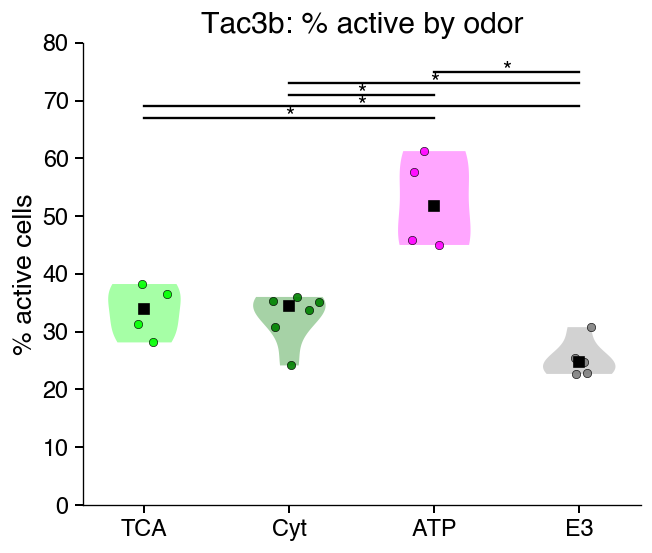

  Saved single-panel: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\Tac3b_percent_violin_helv.svg


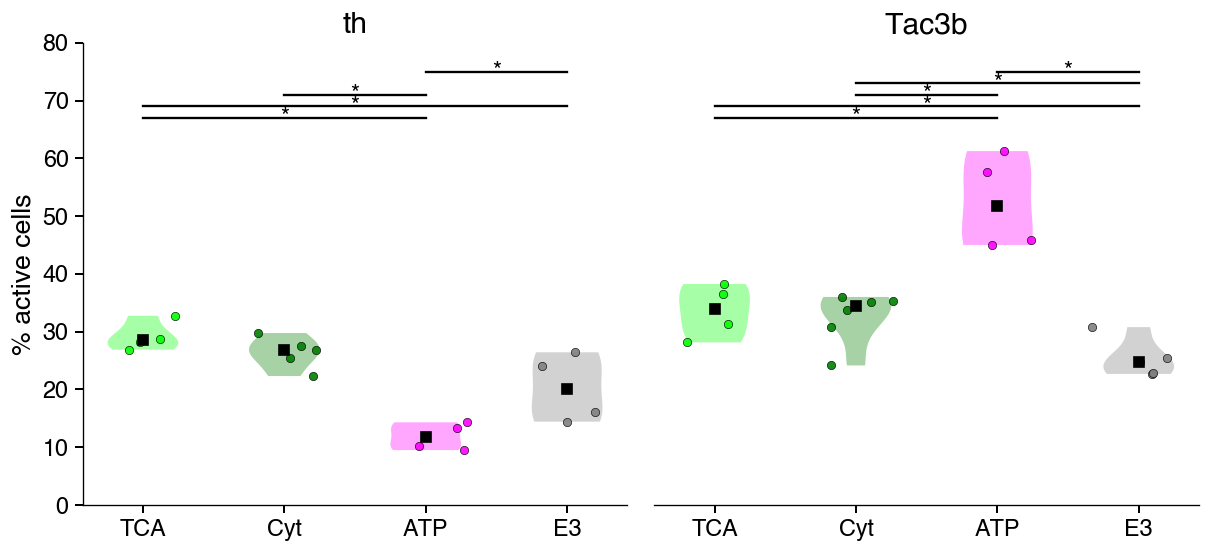

Saved combined figure: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\combined_percent_violin_side_by_side_helv.svg
Saved combined summary: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\combined_stats_summary_allpairs.txt
Done.


In [2]:
"""
Generalized plotting for multiple CSVs / genes.

- Pass a list of csv paths in CSV_PATHS.
- Optionally pass a matching list of modes (e.g. "drd2b", "th", etc.) or let the script infer.
- Produces:
    * one SVG per dataset (single-panel violin + pairwise sig bars)
    * one combined SVG with all datasets plotted side-by-side (matching odors/order)
    * per-dataset pairwise CSVs (_stats_percent_allpairs.csv)
    * a combined summary txt file with Kruskal and readable pairwise summaries

Notes:
- Keeps your Helvetica settings and plotting aesthetics.
- Uses ODOR_LEVELS order to keep x-axis consistent; per-dataset missing odors are omitted.
- If you want different odor order, edit ODOR_LEVELS.
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib import font_manager

# ----------------------------
# Fonts & global plotting
# ----------------------------
HELVETICA_PATH = r"C:\Oded_data\Helvetica.ttf"
try:
    font_manager.fontManager.addfont(HELVETICA_PATH)
    helv_name = font_manager.FontProperties(fname=HELVETICA_PATH).get_name()
except Exception:
    helv_name = "Helvetica"

plt.rcParams.update({
    "font.family": helv_name,
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.dpi": 120
})

# ----------------------------
# User config
# ----------------------------
CSV_PATHS = [
    r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\CaMPARI_HCR_reg\th_activity_quant.csv",
    r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\proccessed imaging data\campari\HCR_Campari_analysis\tac3b_tbr1a\tac3b_quant.csv",

]
# Optional: modes to help column selection. If None, the script will try to infer.
MODES = [ "th", "Tac3b"]  # or e.g. ["drd2b", "th"]

OUT_DIR = os.path.commonprefix(CSV_PATHS).rstrip("\\/")  # where summaries will be stored
if not OUT_DIR:
    OUT_DIR = "."


ODOR_LEVELS = ["TCA", "Cyt", "ATP", "E3"]  # canonical x-order
ODOR_COLOR  = {"TCA": "lime", "Cyt": "green", "ATP": "magenta", "E3": "gray"}

YMAX = 80.0
SIG_START = 65.0
SIG_STEP = 2.0
SIG_FONTSIZE = 14
RNG = np.random.default_rng(0)

# ----------------------------
# Helper utilities (kept & extended)
# ----------------------------
def _find_col_case_insensitive(df, names):
    lowmap = {c.lower(): c for c in df.columns}
    for n in names:
        if n.lower() in lowmap:
            return lowmap[n.lower()]
    # substring search
    for c in df.columns:
        for n in names:
            if n.lower() in c.lower():
                return c
    raise KeyError(f"None of {names} found in columns {list(df.columns)}")

def _find_sample_col(df):
    for cand in ["sample", "Sample", "SAMPLE", "filename", "file"]:
        if cand in df.columns:
            return cand
    # fallback: first object dtype col
    for c in df.columns:
        if df[c].dtype == object:
            return c
    raise KeyError("No 'sample' column found.")

def _guess_mode_from_columns(df):
    # extend if you have more gene names you expect
    known = {
        "drd2b": ["drd2b", "drd2"],
        "th":    ["th", "tyrosine_hydroxylase"],
        "sst":   ["sst", "sst1.1", "sst6", "sst7"],
        "tac3b": ["tac3b", "tachykinin"],
    }
    cols = " ".join(df.columns).lower()
    for mode, tokens in known.items():
        for t in tokens:
            if t in cols:
                return mode
    return None

def load_active_percent(csv_path, mode=None):
    """
    Loads CSV and returns dataframe with columns:
      - sample (string)
      - odor   (parsed from sample, first token before '_')
      - active_percent (float %)
    mode: 'drd2b', 'th' or None to infer
    """
    df = pd.read_csv(csv_path)
    sample_col = _find_sample_col(df)

    if mode is None:
        mode = _guess_mode_from_columns(df)
    if mode is None:
        # try to find columns that look like "X+" or "X_pos"
        lower_cols = [c.lower() for c in df.columns]
        # find any column with '+' in header (e.g., "drd2b+")
        plus_cols = [c for c in df.columns if '+' in c]
        if plus_cols:
            # pick first plus col as pos_col and try to find active/* variant
            pos_col = plus_cols[0]
            # naive active col search
            possible_active = [c for c in df.columns if 'active' in c.lower() and c.lower() in " ".join(lower_cols)]
            active_col = possible_active[0] if possible_active else None
        else:
            pos_col = None
            active_col = None
    else:
        if mode.lower() == "drd2b":
            pos_col    = _find_col_case_insensitive(df, ["drd2b+", "drd2b_pos", "drd2b_count", "drd2b"])
            active_col = _find_col_case_insensitive(df, ["active/drd2b+", "active_drd2b+", "active_drd2b_pos", "active_drd2b", "active_drd2b_count"])
        elif mode.lower() == "th":
            pos_col    = _find_col_case_insensitive(df, ["th+", "th_pos", "th_count", "TH+"])
            active_col = _find_col_case_insensitive(df, ["active/th+", "active_th+", "active_th_pos", "active_th", "active_th_count"])
        else:
            # generic attempt: look for columns containing the mode token
            pos_col = _find_col_case_insensitive(df, [f"{mode}+", f"{mode}_pos", f"{mode}_count", mode])
            active_col = _find_col_case_insensitive(df, [f"active/{mode}+", f"active_{mode}+", f"active_{mode}_pos", f"active_{mode}", f"active_{mode}_count"])

    # final check
    if pos_col is None or active_col is None:
        raise KeyError(f"Could not determine pos/active columns for {csv_path}. Found pos={pos_col}, active={active_col}")

    out = pd.DataFrame({
        "sample": df[sample_col].astype(str),
        "odor":   df[sample_col].astype(str).str.extract(r"^([^_]+)")[0]
    })

    denom = pd.to_numeric(df[pos_col], errors="coerce")
    numer = pd.to_numeric(df[active_col], errors="coerce")

    valid = (denom > 0) & denom.notna()
    active_percent = (numer / denom) * 100.0
    active_percent = active_percent.where(valid)
    active_percent = active_percent.replace([np.inf, -np.inf], np.nan)

    out["active_percent"] = active_percent.astype(float)
    out = out.dropna(subset=["odor", "active_percent"]).copy()
    return out

def make_all_pairs_in_order(odors):
    pairs = []
    for i in range(len(odors)):
        for j in range(i+1, len(odors)):
            pairs.append((odors[i], odors[j]))
    return pairs

def kruskal_and_pairwise_fixed(data, group_col, value_col, odors, correction='fdr_bh'):
    odors_present = [o for o in odors if o in data[group_col].unique()]
    if len(odors_present) < 2:
        return np.nan, np.nan, pd.DataFrame()
    groups = [data.loc[data[group_col]==g, value_col].dropna().values for g in odors_present]
    groups_nonempty = [g for g in groups if len(g) > 0]
    if len(groups_nonempty) < 2:
        return np.nan, np.nan, pd.DataFrame()
    kw_stat, kw_p = stats.kruskal(*groups_nonempty)

    pairs = make_all_pairs_in_order(odors_present)
    rows = []
    for (g1, g2) in pairs:
        x = data.loc[data[group_col]==g1, value_col].dropna().values
        y = data.loc[data[group_col]==g2, value_col].dropna().values
        if len(x)==0 or len(y)==0:
            p_raw = np.nan
            u_stat = np.nan
        else:
            u_stat, p_raw = stats.mannwhitneyu(x, y, alternative='two-sided')
        rows.append({"group1": g1, "group2": g2, "u": float(u_stat) if np.isfinite(u_stat) else np.nan,
                     "p_raw": float(p_raw) if np.isfinite(p_raw) else np.nan})
    df_pairs = pd.DataFrame(rows)

    valid_mask = df_pairs["p_raw"].notna().values
    if valid_mask.sum() > 0:
        _, p_corr, _, _ = multipletests(df_pairs.loc[valid_mask, "p_raw"].values, alpha=0.05, method=correction)
        df_pairs.loc[valid_mask, "p_adj"] = p_corr
        df_pairs["sig"] = df_pairs["p_adj"].apply(lambda p: '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns')
    else:
        df_pairs["p_adj"] = np.nan
        df_pairs["sig"] = 'ns'

    return kw_stat, kw_p, df_pairs

def beautify_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=5, width=1.2)
    ax.grid(False)

def panel_violin(ax, data, odor_levels, title, color_map, rng):
    groups = [data.loc[data["odor"]==o, "active_percent"].values for o in odor_levels]

    parts = ax.violinplot(groups, positions=np.arange(len(odor_levels)),
                          showmeans=False, showextrema=False, showmedians=False)
    for i, body in enumerate(parts['bodies']):
        o = odor_levels[i]
        c = color_map.get(o, 'gray')
        body.set_facecolor(c)
        body.set_edgecolor('none')
        body.set_alpha(0.35)

    # jittered points
    for i, o in enumerate(odor_levels):
        yv = data.loc[data["odor"]==o, "active_percent"].values
        if len(yv) == 0:
            continue
        x = rng.normal(loc=i, scale=0.15, size=len(yv))
        ax.plot(x, yv, 'o', alpha=0.9, markersize=5.0,
                markerfacecolor=color_map.get(o, 'gray'),
                markeredgecolor='black', markeredgewidth=0.4)

    # medians
    meds = [np.median(v) if len(v) else np.nan for v in groups]
    ax.plot(np.arange(len(odor_levels)), meds, 's', color='black', markersize=6, zorder=5)

    ax.set_xticks(np.arange(len(odor_levels)))
    ax.set_xticklabels(odor_levels)
    ax.set_ylabel("% active cells")
    ax.set_title(title)
    ax.set_ylim(0, YMAX)
    beautify_axes(ax)

def add_sig_lines_all_vs_all(ax, odor_levels, stats_df, y_start=SIG_START, y_step=SIG_STEP, show_ns=False):
    bottom, top = ax.get_ylim()
    top = min(top, YMAX)
    y = min(y_start, top - 1.0)
    text_off = 0.1

    if stats_df is None or stats_df.empty:
        return

    for _, r in stats_df.iterrows():
        g1, g2 = r["group1"], r["group2"]
        lab = r.get("sig", "ns")
        if (lab == 'ns') and (not show_ns):
            y = min(top - 0.5, y + y_step)
            continue
        # skip if groups not present in this plotting odor_levels
        if (g1 not in odor_levels) or (g2 not in odor_levels):
            continue
        x1 = odor_levels.index(g1)
        x2 = odor_levels.index(g2)
        ax.plot([x1, x2], [y, y], color='black', lw=1.4, clip_on=False)
        ax.text((x1+x2)/2, y + text_off, lab, ha='center', va='center',
                fontsize=SIG_FONTSIZE, clip_on=False)
        y = min(top - 0.5, y + y_step)

    ax.set_ylim(0, YMAX)

def summarize_pairs_readable(df, data, odor_levels, tag):
    if df.empty:
        return f"[{tag}] No valid pairwise comparisons.\n", df
    med_map = {o: np.median(data.loc[data['odor']==o, 'active_percent'].dropna().values)
               if (data['odor']==o).any() else np.nan for o in odor_levels}
    out = df.copy()
    out["median_g1"] = out["group1"].map(med_map)
    out["median_g2"] = out["group2"].map(med_map)
    out["delta_med"] = out["median_g1"] - out["median_g2"]
    out["direction"] = np.where(out["delta_med"] > 0,
                                out["group1"] + " > " + out["group2"],
                                np.where(out["delta_med"] < 0,
                                         out["group2"] + " > " + out["group1"],
                                         "no difference"))
    sort_cols = [c for c in ["p_adj", "p_raw"] if c in out.columns]
    out = out.sort_values(by=sort_cols, ascending=True)

    lines = [f"[{tag}] Pairwise Mann–Whitney (BH-FDR within panel):"]
    for _, r in out.iterrows():
        p_adj = r.get('p_adj', np.nan)
        p_str = f"{p_adj:.3g}" if np.isfinite(p_adj) else f"raw {r['p_raw']:.3g}"
        sig = r.get('sig', '—')
        lines.append(
            f"  {r['group1']} vs {r['group2']}: p={p_str} ({sig}), "
            f"medians {r['group1']}={r['median_g1']:.2f}%, {r['group2']}={r['median_g2']:.2f}% "
            f"→ {r['direction']} (Δ={r['delta_med']:.2f})"
        )
    lines.append("")
    return "\n".join(lines), out

# ----------------------------
# Main processing functions
# ----------------------------
def process_dataset(csv_path, mode=None, odor_order=ODOR_LEVELS, color_map=ODOR_COLOR, out_dir=OUT_DIR):
    """
    Loads, computes stats, writes pairwise CSV, returns (label, df, kw_stat, kw_p, pw_df, readable_text)
    """
    label = mode if mode is not None else os.path.splitext(os.path.basename(csv_path))[0]
    try:
        df = load_active_percent(csv_path, mode=mode)
    except Exception as exc:
        raise RuntimeError(f"Failed to load {csv_path} (label={label}): {exc}")
    print(f'df  print out {df}')
    # choose odors for plotting for this dataset (respecting canonical order)
    odors_plot = [o for o in odor_order if o in df['odor'].unique()]
    if len(odors_plot) < 2:
        # fallback to dataset unique odors if none match canonical list
        uniq = sorted(df['odor'].unique())
        odors_plot = uniq

    kw_stat, kw_p, pw = kruskal_and_pairwise_fixed(df, 'odor', 'active_percent', odors_plot)
    stats_csv_out = os.path.join(out_dir, f"{label}_stats_percent_allpairs.csv")
    pw.to_csv(stats_csv_out, index=False)

    readable_txt, pw_ext = summarize_pairs_readable(pw, df, odors_plot, tag=label.upper())
    return {
        "label": label,
        "df": df,
        "odors_plot": odors_plot,
        "kw_stat": kw_stat,
        "kw_p": kw_p,
        "pw": pw,
        "readable": readable_txt,
        "stats_csv": stats_csv_out,
        "csv_path": csv_path
    }

def make_and_save_single_panel(result, color_map=ODOR_COLOR, rng=RNG, out_dir=OUT_DIR):
    label = result["label"]
    df = result["df"]
    odors_plot = result["odors_plot"]

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    panel_violin(ax, df, odors_plot, f"{label}: % active by odor", color_map, rng)
    add_sig_lines_all_vs_all(ax, odors_plot, result["pw"], show_ns=False)

    out_svg = os.path.join(out_dir, f"{label}_percent_violin_helv.svg")
  #  fig.savefig(out_svg, format="svg", bbox_inches="tight")
    plt.show(fig)
    return out_svg

def make_and_save_combined(results, color_map=ODOR_COLOR, rng=RNG, out_dir=OUT_DIR):
    # Determine combined odor set: intersection of odors across all results if >=2, else union
    all_odors_sets = [set(r["odors_plot"]) for r in results]
    intersection = set.intersection(*all_odors_sets) if results else set()
    if len(intersection) >= 2:
        odors_combined = [o for o in ODOR_LEVELS if o in intersection]
    else:
        # union / canonical ordering
        union = set().union(*all_odors_sets)
        odors_combined = [o for o in ODOR_LEVELS if o in union]
        # add any remaining not in ODOR_LEVELS
        odors_combined += sorted([o for o in union if o not in odors_combined])

    n = len(results)
    ncols = n
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    if n == 1:
        axes = [axes]

    for ax, res in zip(axes, results):
        panel_violin(ax, res["df"], odors_combined, res["label"], color_map, rng)
        add_sig_lines_all_vs_all(ax, odors_combined, res["pw"], show_ns=False)
        # remove y axis for all but first
        if ax is not axes[0]:
            ax.set_ylabel(None)
            ax.set_yticks([])
            ax.spines['left'].set_visible(False)

    fig.subplots_adjust(wspace=0.05)
    out_svg = os.path.join(out_dir, "combined_percent_violin_side_by_side_helv.svg")
#    fig.savefig(out_svg, format="svg", bbox_inches="tight")
    plt.show(fig)
    return out_svg

# ----------------------------
# Run everything
# ----------------------------
def main(csv_paths, modes=None, out_dir=OUT_DIR):
    if modes is None:
        modes = [None] * len(csv_paths)
    if len(modes) != len(csv_paths):
        raise ValueError("modes list must match csv_paths length or be None.")

    os.makedirs(out_dir, exist_ok=True)
    results = []
    summaries = []
    for csv_path, mode in zip(csv_paths, modes):
        print(f"Processing: {csv_path}  (mode={mode})")
        res = process_dataset(csv_path, mode=mode, odor_order=ODOR_LEVELS, color_map=ODOR_COLOR, out_dir=out_dir)
        results.append(res)

        # single panel saved
        fig_path = make_and_save_single_panel(res, color_map=ODOR_COLOR, rng=RNG, out_dir=out_dir)
        print(f"  Saved single-panel: {fig_path}")
        summaries.append(f"{res['label']}\nKruskal H={res['kw_stat']:.3f} p={res['kw_p']}\n")
        summaries.append(res['readable'])
        summaries.append(f"Pairwise CSV: {res['stats_csv']}\n\n")

    # combined figure
    combined_path = make_and_save_combined(results, color_map=ODOR_COLOR, rng=RNG, out_dir=out_dir)
    print(f"Saved combined figure: {combined_path}")

    # combined summary text
    summary_txt_path = os.path.join(out_dir, "combined_stats_summary_allpairs.txt")
    with open(summary_txt_path, "w", encoding="utf-8") as f:
        f.write("Combined dataset summaries\n\n")
        for s in summaries:
            f.write(s)
            f.write("\n")
        f.write(f"Combined figure: {combined_path}\n")
    print(f"Saved combined summary: {summary_txt_path}")

    return {
        "results": results,
        "combined_figure": combined_path,
        "summary_txt": summary_txt_path
    }

if __name__ == "__main__":
    # run
    out = main(CSV_PATHS, modes=MODES, out_dir=OUT_DIR)
    print("Done.")
